# Thailand Rain Models - Seasonal Cross-Validation

`Thailand_Rain_V1.ipynb` reports one number per horizon from a single chronological split.
That split put **May-June 2026 (monsoon onset, 37% hourly rain rate)** in the test set and
**March-April 2026 (dry season, 6-8%)** in validation. The headline scores are therefore
measured on the wettest, easiest weeks of the year.

This notebook answers: **how does performance actually vary across the seasons?**

## Why not just re-score the V1 models month by month

The V1 models were *trained* on July 2025 - March 2026. Scoring them on those months would
measure memorisation, not skill. Every month needs a model that never saw it.

## Design

**Month-blocked cross-validation, 4 folds of 3 consecutive months.** Each fold trains on the
other 9 months and predicts its own 3. Every one of the 12 months therefore gets an
out-of-sample prediction exactly once, and metrics are then reported **per month**
(fold size limits training data, not reporting granularity).

A **24-hour purge buffer** is dropped from training on each side of the test block. Features
look back 24h and labels look forward 6h, so rows adjacent to the boundary would otherwise
share raw observations with the test block.

## How to read the result

With only 12 months available, a held-out block is also a *season the model never trained on*.
A drop in, say, July-September does not mean "bad at monsoon" - it means "never shown a
monsoon". That is precisely the limitation extra years of data would remove, and the size of
the gap is the quantified cost of having a single year.

## 1. Setup

In [1]:
import gc
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

PRECOMPUTE_TABLE_NAME = '"OM_THAILAND_DATA_PRECOMPUTE"'
PROJECT_ROOT = Path.cwd()
V1_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_thailand_rain_any_final_4_neighbor_models"
OUTPUT_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_thailand_rain_any_seasonal_cv"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
MODEL_PLAN = {1: "lightgbm", 2: "lightgbm", 3: "hist_gradient_boosting", 6: "hist_gradient_boosting"}
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)
RANDOM_STATE = 42

# Hours of training data dropped either side of each test block.
PURGE_HOURS = 24

# Operating thresholds chosen by V1 on its single dry-season validation split. Reused here so
# every month is scored at the same operating point - that is the comparison of interest.
try:
    V1_META = json.loads((V1_DIR / "final_4_metadata.json").read_text(encoding="utf-8"))
    V1_THRESHOLDS = {int(k): float(v) for k, v in V1_META["selected_probability_thresholds"].items()}
    print("Loaded V1 thresholds:", V1_THRESHOLDS)
except FileNotFoundError:
    V1_THRESHOLDS = {1: 0.65, 2: 0.60, 3: 0.40, 6: 0.40}
    print("V1 metadata not found, using fallback thresholds:", V1_THRESHOLDS)

Loaded V1 thresholds: {3: 0.40000000000000013, 6: 0.40000000000000013, 1: 0.6500000000000001, 2: 0.6000000000000002}


## 3. Feature Columns

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
TARGET_COLUMNS = [f"rain_any_next_{h}h" for h in HORIZONS]
print(f"Features: {len(FEATURE_COLUMNS)}, targets: {TARGET_COLUMNS}")

Features: 66, targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load Data

Identical streaming loader to V1: server-side cursor into preallocated float32, so the full
6.8M x 66 panel costs ~1.8 GB rather than the ~4 GB a float64 DataFrame would take.

In [4]:
ROW_FILTER_SQL = f'''
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND rain_any_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
'''


def connect():
    return psycopg2.connect(**DB_CONFIG)


def read_training_data(batch_size=250_000):
    feature_sql = ",\n        ".join(
        f"COALESCE({c}::real, 'NaN'::real) AS {c}" for c in FEATURE_COLUMNS
    )
    target_sql = ",\n        ".join(f"{t}::smallint" for t in TARGET_COLUMNS)
    query = f'''
    SELECT grid_number, local_forecast_time,
        {feature_sql},
        {target_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    {ROW_FILTER_SQL}
    ORDER BY local_forecast_time, grid_number
    '''
    with connect() as conn:
        with conn.cursor() as cur:
            cur.execute(f"SELECT count(*) FROM {PRECOMPUTE_TABLE_NAME} {ROW_FILTER_SQL}")
            n_rows = cur.fetchone()[0]
        print(f"Allocating {n_rows:,} x {len(FEATURE_COLUMNS)} float32 "
              f"({n_rows * len(FEATURE_COLUMNS) * 4 / 1e9:.2f} GB)")

        x = np.empty((n_rows, len(FEATURE_COLUMNS)), dtype="float32")
        y = np.empty((n_rows, len(TARGET_COLUMNS)), dtype="int8")
        t = np.empty(n_rows, dtype="datetime64[s]")
        n_feat = len(FEATURE_COLUMNS)
        filled = 0
        with conn.cursor(name="thailand_cv_stream") as cur:
            cur.itersize = batch_size
            cur.execute(query)
            while filled < n_rows:
                batch = cur.fetchmany(batch_size)
                if not batch:
                    break
                block = np.asarray(batch, dtype="object")
                take = len(batch)
                t[filled:filled + take] = block[:, 1].astype("datetime64[s]")
                x[filled:filled + take] = block[:, 2:2 + n_feat].astype("float32")
                y[filled:filled + take] = block[:, 2 + n_feat:].astype("int8")
                filled += take
                print(f"  {filled:,} / {n_rows:,}", end="\r", flush=True)
        print()
    return x[:filled], y[:filled], t[:filled]


started = time.time()
x_all, y_all, forecast_time = read_training_data()
print(f"Loaded {x_all.shape[0]:,} rows in {(time.time()-started)/60:.1f} min "
      f"({x_all.nbytes/1e9:.2f} GB)")

Allocating 6,808,840 x 66 float32 (1.80 GB)



Loaded 6,808,840 rows in 8.2 min (1.80 GB)


## 5. Define Month-Blocked Folds

In [5]:
months = pd.PeriodIndex(pd.to_datetime(forecast_time), freq="M")
month_key = months.astype(str).to_numpy()
unique_months = sorted(pd.unique(month_key))
print(f"{len(unique_months)} months: {unique_months[0]} .. {unique_months[-1]}")

FOLD_SIZE = 3
folds = [unique_months[i:i + FOLD_SIZE] for i in range(0, len(unique_months), FOLD_SIZE)]

purge = np.timedelta64(PURGE_HOURS, "h")
fold_table = []
for i, fold_months in enumerate(folds):
    test_mask = np.isin(month_key, fold_months)
    t0, t1 = forecast_time[test_mask].min(), forecast_time[test_mask].max()
    train_mask = ~test_mask & ((forecast_time < t0 - purge) | (forecast_time > t1 + purge))
    fold_table.append({
        "fold": i,
        "test_months": ", ".join(fold_months),
        "test_rows": int(test_mask.sum()),
        "train_rows": int(train_mask.sum()),
        "purged_rows": int(len(forecast_time) - test_mask.sum() - train_mask.sum()),
        "test_rain_rate_1h": float(y_all[test_mask, 0].mean()),
    })
display(pd.DataFrame(fold_table))

12 months: 2025-07 .. 2026-06


,fold,test_months,test_rows,train_rows,purged_rows,test_rain_rate_1h
0,0,"2025-07, 2025-08, 2025-09",1454418,5334430,19992,0.4257
1,1,"2025-10, 2025-11, 2025-12",1839264,4929592,39984,0.1961
2,2,"2026-01, 2026-02, 2026-03",1799280,4969576,39984,0.0561
3,3,"2026-04, 2026-05, 2026-06",1715878,5072970,19992,0.2584


## 6. Run Cross-Validation

Each fold trains all four horizon models and writes its predictions into an out-of-fold
probability matrix. Models are released after each fold to keep peak memory near the
single-model level.

In [6]:
oof_probabilities = np.full((x_all.shape[0], len(HORIZONS)), np.nan, dtype="float32")
fold_log = []
cv_started = time.time()

for fold_index, fold_months in enumerate(folds):
    test_mask = np.isin(month_key, fold_months)
    t0, t1 = forecast_time[test_mask].min(), forecast_time[test_mask].max()
    train_mask = ~test_mask & ((forecast_time < t0 - purge) | (forecast_time > t1 + purge))

    x_train = x_all[train_mask]
    x_test = x_all[test_mask]
    print(f"\n=== fold {fold_index}: test {fold_months} "
          f"({test_mask.sum():,} rows, train {train_mask.sum():,}) ===", flush=True)

    for horizon_index, horizon in enumerate(HORIZONS):
        model_name = MODEL_PLAN[horizon]
        y_train = y_all[train_mask, horizon_index]
        started = time.time()

        if model_name == "lightgbm":
            scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
            model = LGBMClassifier(
                objective="binary", n_estimators=500, learning_rate=0.04, num_leaves=63,
                min_child_samples=80, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
                scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                n_jobs=-1, verbose=-1,
            )
            model.fit(x_train, y_train)
        else:
            model = HistGradientBoostingClassifier(
                learning_rate=0.06, max_iter=250, max_leaf_nodes=31,
                l2_regularization=0.05, random_state=RANDOM_STATE, early_stopping=False,
            )
            model.fit(x_train, y_train)

        oof_probabilities[test_mask, horizon_index] = model.predict_proba(x_test)[:, 1].astype("float32")
        elapsed = time.time() - started
        fold_log.append({"fold": fold_index, "horizon_h": horizon, "model": model_name,
                         "train_rows": int(train_mask.sum()), "fit_seconds": elapsed})
        print(f"  {horizon}h {model_name}: {elapsed/60:.1f} min", flush=True)

        del model
        gc.collect()

    del x_train, x_test
    gc.collect()

coverage = float(np.isfinite(oof_probabilities).all(axis=1).mean())
print(f"\nCV finished in {(time.time()-cv_started)/60:.1f} min; "
      f"rows with out-of-fold predictions: {coverage:.4f}")
display(pd.DataFrame(fold_log))


=== fold 0: test ['2025-07', '2025-08', '2025-09'] (1,454,418 rows, train 5,334,430) ===


  1h lightgbm: 2.8 min


  2h lightgbm: 2.8 min


  3h hist_gradient_boosting: 2.2 min


  6h hist_gradient_boosting: 4.2 min


...

  2h lightgbm: 2.5 min


  3h hist_gradient_boosting: 2.0 min


  6h hist_gradient_boosting: 1.9 min



CV finished in 41.0 min; rows with out-of-fold predictions: 1.0000


,fold,horizon_h,model,train_rows,fit_seconds
0,0,1,lightgbm,5334430,166.9109
1,0,2,lightgbm,5334430,167.5266
2,0,3,hist_gradient_boosting,5334430,131.7701
3,0,6,hist_gradient_boosting,5334430,250.1137
4,1,1,lightgbm,4929592,185.3328
5,1,2,lightgbm,4929592,199.5957
6,1,3,hist_gradient_boosting,4929592,118.6803
7,1,6,hist_gradient_boosting,4929592,115.0692
8,2,1,lightgbm,4969576,166.4352
9,2,2,lightgbm,4969576,159.8062


## 7. Per-Month Out-Of-Sample Metrics

Every month below was predicted by a model that never saw it. `rain_rate` is the month's own
base rate - the single biggest driver of how easy or hard that month is.

In [7]:
def month_metrics(month, horizon_index, horizon):
    mask = (month_key == month) & np.isfinite(oof_probabilities[:, horizon_index])
    y_true = y_all[mask, horizon_index]
    probabilities = oof_probabilities[mask, horizon_index]
    row = {
        "month": month,
        "horizon_h": horizon,
        "model": MODEL_PLAN[horizon],
        "rows": int(mask.sum()),
        "rain_rate": float(y_true.mean()),
    }
    if y_true.min() == y_true.max():          # degenerate month, AUC undefined
        row.update({"roc_auc": np.nan, "pr_auc": np.nan, "brier_score": np.nan})
    else:
        row.update({
            "roc_auc": float(roc_auc_score(y_true, probabilities)),
            "pr_auc": float(average_precision_score(y_true, probabilities)),
            "brier_score": float(brier_score_loss(y_true, probabilities)),
        })

    threshold = V1_THRESHOLDS[horizon]
    y_pred = (probabilities >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    row.update({
        "v1_threshold": threshold,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "predicted_rain_rate": float(y_pred.mean()),
        "false_positives": int(fp),
        "false_negatives": int(fn),
    })

    # Best achievable F1 this month, and the threshold that reaches it.
    best_f1, best_threshold = -1.0, np.nan
    for candidate in PROBABILITY_THRESHOLDS_TO_TEST:
        score = f1_score(y_true, (probabilities >= candidate).astype("int8"), zero_division=0)
        if score > best_f1:
            best_f1, best_threshold = float(score), float(candidate)
    row.update({"best_f1": best_f1, "best_threshold": best_threshold,
                "f1_lost_to_fixed_threshold": best_f1 - row["f1"]})
    return row


monthly = pd.DataFrame([
    month_metrics(month, i, horizon)
    for i, horizon in enumerate(HORIZONS)
    for month in unique_months
]).sort_values(["horizon_h", "month"])

for horizon in HORIZONS:
    print(f"\n===== {horizon}h ({MODEL_PLAN[horizon]}) =====")
    display(monthly[monthly["horizon_h"] == horizon][
        ["month", "rows", "rain_rate", "roc_auc", "pr_auc", "brier_score",
         "precision", "recall", "f1", "best_f1", "best_threshold"]
    ].to_string(index=False))


===== 1h (lightgbm) =====


'  month   rows  rain_rate  roc_auc  pr_auc  brier_score  precision  recall     f1  best_f1  best_threshold\n2025-07 234906     0.4893   0.9288  0.9312       0.1686     0.7310  0.9426 0.8234   0.8465          0.8500\n2025-08 619752     0.3667   0.9226  0.8800       0.1519     0.7056  0.8917 0.7878   0.7984          0.7500\n2025-09 599760     0.4617   0.9088  0.8953       0.1660     0.7269  0.9135 0.8096   0.8181          0.7500\n2025-10 619752     0.2837   0.9165  0.8235       0.1330     0.6919  0.8115 0.7470   0.7477          0.7000\n2025-11 599760     0.2347   0.9603  0.8892       0.0849     0.7489  0.8589 0.8002   0.8025          0.7000\n2025-12 619752     0.0713   0.9678  0.7548       0.0387     0.6848  0.6945 0.6896   0.6896          0.6500\n2026-01 619752     0.0251   0.9832  0.6885       0.0134     0.7312  0.5222 0.6093   0.6449          0.4500\n2026-02 559776     0.0774   0.9550  0.6890       0.0410     0.7221  0.5195 0.6043   0.6425          0.4500\n2026-03 619752     0.0679  


===== 2h (lightgbm) =====


'  month   rows  rain_rate  roc_auc  pr_auc  brier_score  precision  recall     f1  best_f1  best_threshold\n2025-07 234906     0.5693   0.9131  0.9372       0.1646     0.7478  0.9479 0.8360   0.8512          0.8000\n2025-08 619752     0.4521   0.9068  0.8953       0.1576     0.7240  0.8996 0.8023   0.8098          0.7000\n2025-09 599760     0.5580   0.8943  0.9152       0.1597     0.7604  0.9199 0.8326   0.8382          0.7000\n2025-10 619752     0.3676   0.8961  0.8440       0.1471     0.7068  0.8289 0.7630   0.7637          0.6500\n2025-11 599760     0.2858   0.9523  0.8970       0.0916     0.7571  0.8638 0.8069   0.8084          0.6500\n2025-12 619752     0.0956   0.9545  0.7545       0.0481     0.6919  0.6704 0.6810   0.6826          0.5500\n2026-01 619752     0.0346   0.9766  0.6818       0.0179     0.7606  0.4631 0.5757   0.6274          0.3500\n2026-02 559776     0.1101   0.9371  0.6902       0.0555     0.7443  0.4716 0.5774   0.6376          0.3500\n2026-03 619752     0.1010  


===== 3h (hist_gradient_boosting) =====


'  month   rows  rain_rate  roc_auc  pr_auc  brier_score  precision  recall     f1  best_f1  best_threshold\n2025-07 234906     0.6253   0.9043  0.9435       0.1229     0.8036  0.9250 0.8600   0.8622          0.5000\n2025-08 619752     0.5153   0.8957  0.9056       0.1307     0.7759  0.8734 0.8218   0.8218          0.4000\n2025-09 599760     0.6259   0.8849  0.9283       0.1323     0.8089  0.9018 0.8528   0.8530          0.4500\n2025-10 619752     0.4315   0.8826  0.8579       0.1365     0.7379  0.8227 0.7780   0.7780          0.4000\n2025-11 599760     0.3230   0.9471  0.9020       0.0855     0.7750  0.8597 0.8152   0.8156          0.4500\n2025-12 619752     0.1154   0.9433  0.7494       0.0518     0.7021  0.6471 0.6735   0.6766          0.3500\n2026-01 619752     0.0426   0.9702  0.6699       0.0225     0.7098  0.5044 0.5898   0.6159          0.2500\n2026-02 559776     0.1374   0.9229  0.6885       0.0698     0.7006  0.5306 0.6039   0.6383          0.2500\n2026-03 619752     0.1293  


===== 6h (hist_gradient_boosting) =====


'  month   rows  rain_rate  roc_auc  pr_auc  brier_score  precision  recall     f1  best_f1  best_threshold\n2025-07 234906     0.7315   0.8920  0.9583       0.1178     0.8193  0.9622 0.8850   0.8899          0.5500\n2025-08 619752     0.6484   0.8827  0.9331       0.1326     0.7941  0.9297 0.8565   0.8586          0.4500\n2025-09 599760     0.7594   0.8735  0.9555       0.1181     0.8361  0.9513 0.8900   0.8912          0.4500\n2025-10 619752     0.5682   0.8682  0.8983       0.1460     0.7744  0.8640 0.8168   0.8168          0.4000\n2025-11 599760     0.3994   0.9419  0.9183       0.0951     0.7998  0.8675 0.8323   0.8331          0.4500\n2025-12 619752     0.1630   0.9216  0.7538       0.0726     0.7020  0.6461 0.6729   0.6764          0.3500\n2026-01 619752     0.0625   0.9593  0.6774       0.0326     0.6893  0.5192 0.5923   0.6206          0.2500\n2026-02 559776     0.2038   0.9055  0.7220       0.0961     0.7068  0.5799 0.6371   0.6652          0.2500\n2026-03 619752     0.2004  

## 8. Seasonal Spread vs The V1 Headline

In [8]:
v1_metrics = pd.read_csv(V1_DIR / "final_4_metrics.csv")
v1_test = v1_metrics[v1_metrics["split"] == "test"].set_index("horizon_h")
v1_selected = pd.read_csv(V1_DIR / "final_4_selected_threshold_metrics.csv").set_index("horizon_h")

summary = []
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    summary.append({
        "horizon_h": horizon,
        "V1_headline_roc_auc": float(v1_test.loc[horizon, "roc_auc"]),
        "CV_mean_roc_auc": float(sub["roc_auc"].mean()),
        "CV_worst_month_roc_auc": float(sub["roc_auc"].min()),
        "CV_worst_month": sub.loc[sub["roc_auc"].idxmin(), "month"],
        "V1_headline_f1": float(v1_selected.loc[horizon, "f1"]),
        "CV_mean_f1": float(sub["f1"].mean()),
        "CV_worst_month_f1": float(sub["f1"].min()),
        "f1_spread": float(sub["f1"].max() - sub["f1"].min()),
        "best_threshold_min": float(sub["best_threshold"].min()),
        "best_threshold_max": float(sub["best_threshold"].max()),
    })
summary = pd.DataFrame(summary)
display(summary)

print("\nInterpretation")
print("- V1_headline_* come from the single May-June 2026 monsoon test split.")
print("- CV_mean_* average the 12 out-of-sample months, each predicted by a model that never saw it.")
print("- f1_spread is how much F1 swings between the best and worst month at a FIXED threshold.")
print("- best_threshold_min/max show how far the ideal operating point drifts across seasons.")

,horizon_h,V1_headline_roc_auc,CV_mean_roc_auc,CV_worst_month_roc_auc,CV_worst_month,V1_headline_f1,CV_mean_f1,CV_worst_month_f1,f1_spread,best_threshold_min,best_threshold_max
0,1,0.9142,0.9383,0.9088,2025-09,0.7871,0.7142,0.5332,0.2902,0.4500,0.8500
1,2,0.8917,0.9210,0.8840,2026-05,0.7981,0.7139,0.4974,0.3386,0.3000,0.8000
2,3,0.8791,0.9090,0.8681,2026-05,0.8150,0.7293,0.5256,0.3344,0.2000,0.5000
3,6,0.8620,0.8930,0.8460,2026-05,0.8565,0.7586,0.5694,0.3206,0.2500,0.5500



Interpretation
- V1_headline_* come from the single May-June 2026 monsoon test split.
- CV_mean_* average the 12 out-of-sample months, each predicted by a model that never saw it.
- f1_spread is how much F1 swings between the best and worst month at a FIXED threshold.
- best_threshold_min/max show how far the ideal operating point drifts across seasons.


## 9. Charts

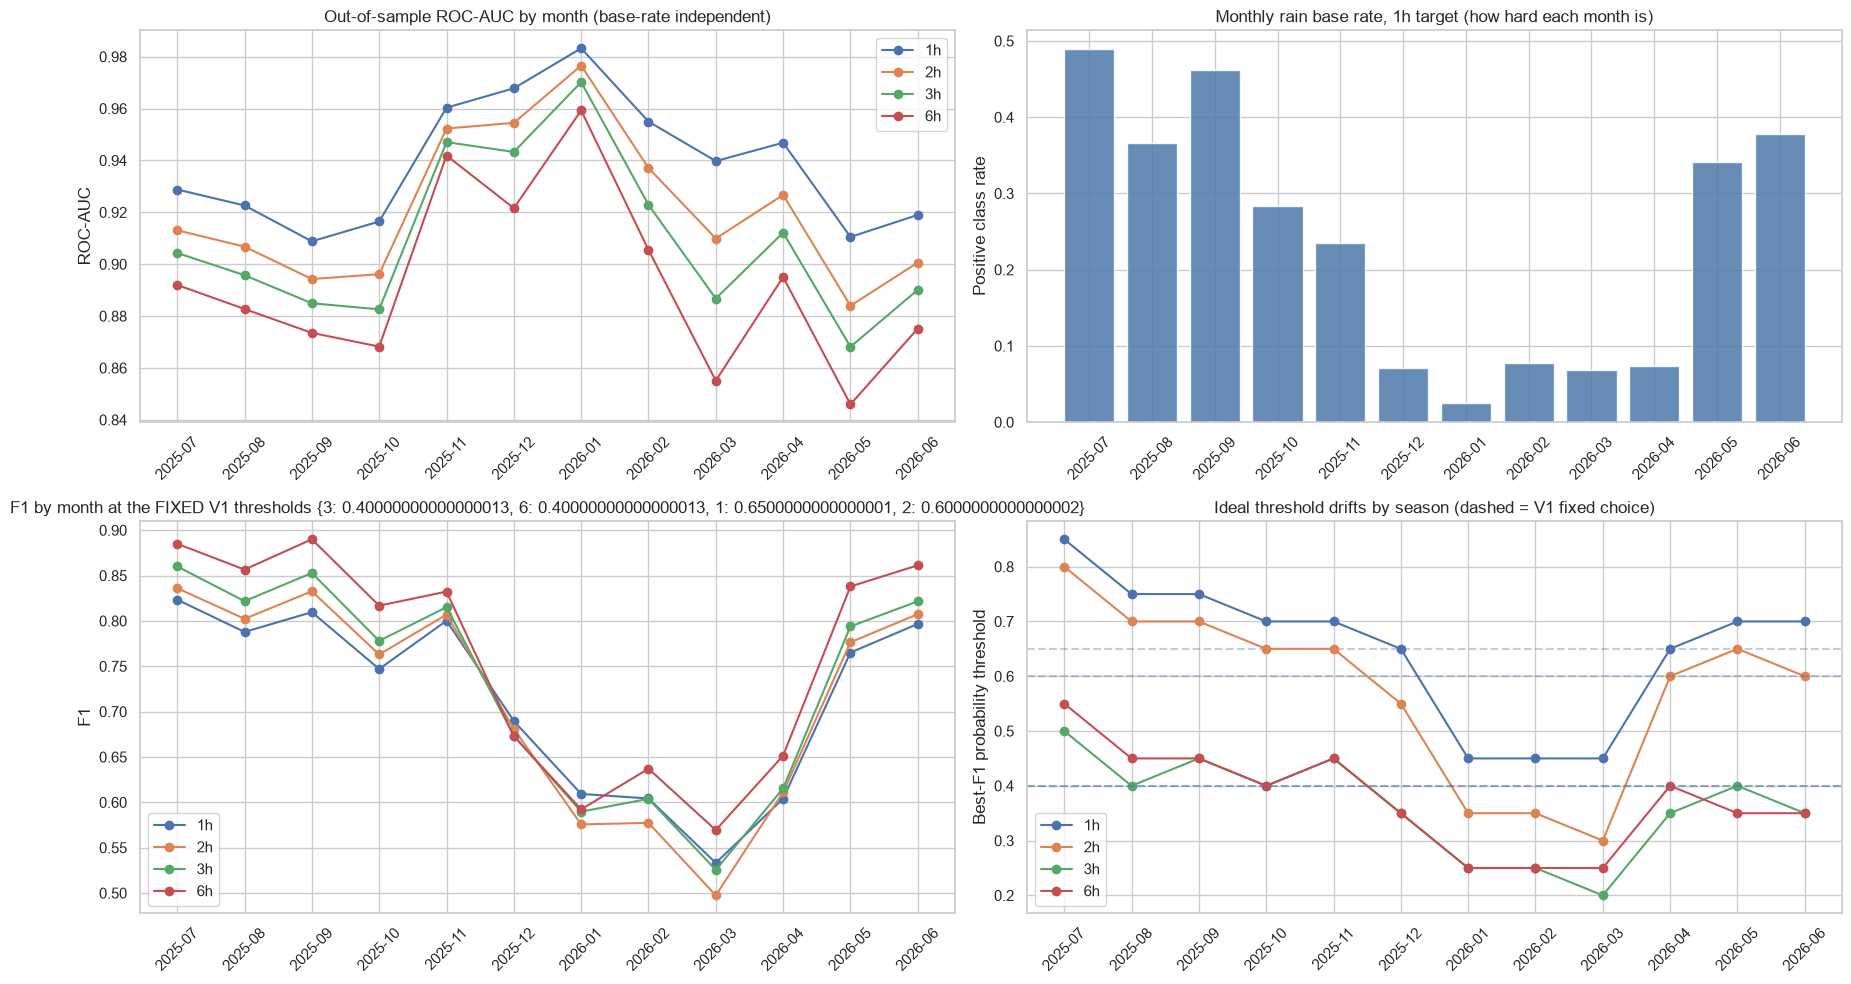

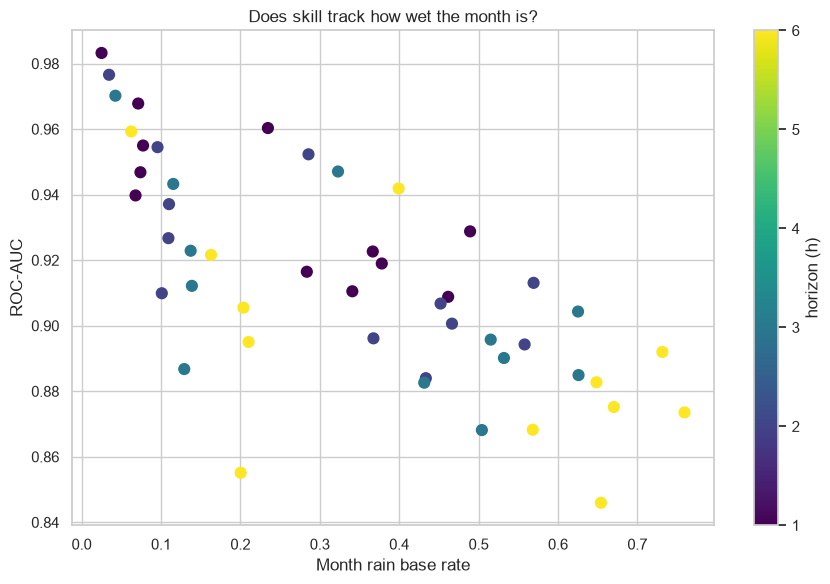

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

ax = axes[0][0]
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.plot(sub["month"], sub["roc_auc"], marker="o", label=f"{horizon}h")
ax.set_title("Out-of-sample ROC-AUC by month (base-rate independent)")
ax.set_ylabel("ROC-AUC"); ax.legend(); ax.tick_params(axis="x", rotation=45)

ax = axes[0][1]
sub1 = monthly[monthly["horizon_h"] == 1]
ax.bar(sub1["month"], sub1["rain_rate"], color="#4c78a8", alpha=0.85)
ax.set_title("Monthly rain base rate, 1h target (how hard each month is)")
ax.set_ylabel("Positive class rate"); ax.tick_params(axis="x", rotation=45)

ax = axes[1][0]
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.plot(sub["month"], sub["f1"], marker="o", label=f"{horizon}h")
ax.set_title(f"F1 by month at the FIXED V1 thresholds {V1_THRESHOLDS}")
ax.set_ylabel("F1"); ax.legend(); ax.tick_params(axis="x", rotation=45)

ax = axes[1][1]
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.plot(sub["month"], sub["best_threshold"], marker="o", label=f"{horizon}h")
    ax.axhline(V1_THRESHOLDS[horizon], linestyle="--", alpha=0.35)
ax.set_title("Ideal threshold drifts by season (dashed = V1 fixed choice)")
ax.set_ylabel("Best-F1 probability threshold"); ax.legend(); ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(monthly["rain_rate"], monthly["roc_auc"], c=monthly["horizon_h"], cmap="viridis", s=60)
ax.set_xlabel("Month rain base rate"); ax.set_ylabel("ROC-AUC")
ax.set_title("Does skill track how wet the month is?")
plt.colorbar(ax.collections[0], label="horizon (h)")
plt.tight_layout()
plt.show()

## 10. Save Results

In [10]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
monthly.to_csv(OUTPUT_DIR / "seasonal_cv_monthly_metrics.csv", index=False)
summary.to_csv(OUTPUT_DIR / "seasonal_cv_summary_vs_v1.csv", index=False)
pd.DataFrame(fold_log).to_csv(OUTPUT_DIR / "seasonal_cv_fold_log.csv", index=False)
pd.DataFrame(fold_table).to_csv(OUTPUT_DIR / "seasonal_cv_folds.csv", index=False)

metadata = {
    "purpose": "month-blocked CV to measure seasonal variation hidden by the V1 single split",
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "fold_size_months": FOLD_SIZE,
    "n_folds": len(folds),
    "purge_hours": PURGE_HOURS,
    "folds": [list(f) for f in folds],
    "model_plan": MODEL_PLAN,
    "v1_thresholds_used": V1_THRESHOLDS,
    "rows": int(x_all.shape[0]),
    "oof_coverage": coverage,
    "summary_vs_v1": summary.to_dict(orient="records"),
    "caveat": (
        "Only 12 months exist, so each held-out block is also an unseen season. "
        "Degradation mixes 'harder season' with 'season never trained on'; "
        "multi-year data is required to separate the two."
    ),
}
(OUTPUT_DIR / "seasonal_cv_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print(f"Saved seasonal CV results to {OUTPUT_DIR}")

Saved seasonal CV results to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_thailand_rain_any_seasonal_cv
